In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

In [9]:
svm_acc = accuracy_score(y_test, y_pred)
print(f"SVM 准确率: {svm_acc:.4f}")

SVM 准确率: 0.9806


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9722    0.9722    0.9722        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9459    0.9722    0.9589        36
           5     0.9737    1.0000    0.9867        37
           6     0.9730    1.0000    0.9863        36
           7     0.9459    0.9722    0.9589        36
           8     1.0000    0.9429    0.9706        35
           9     1.0000    0.9444    0.9714        36

    accuracy                         0.9806       360
   macro avg     0.9811    0.9804    0.9805       360
weighted avg     0.9810    0.9806    0.9805       360



In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
cm = confusion_matrix(y_test, y_pred)

In [13]:
cm

array([[36,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 35,  0,  0,  1,  0,  0,  0,  0,  0],
       [ 0,  0, 35,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 37,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 35,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0, 37,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 36,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0, 35,  0,  0],
       [ 0,  1,  0,  0,  1,  0,  0,  0, 33,  0],
       [ 0,  0,  0,  0,  0,  0,  1,  1,  0, 34]])

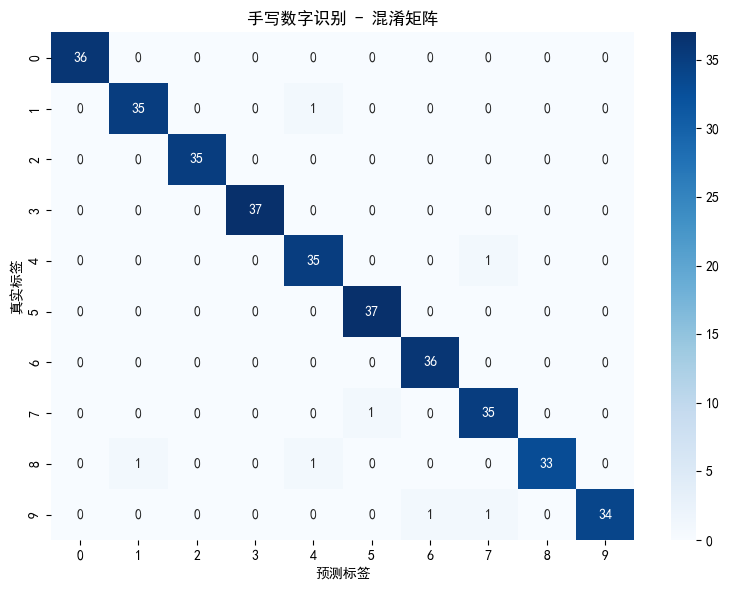

In [16]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.title("手写数字识别 - 混淆矩阵")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

errors = np.where(y_pred != y_test)[0]
errors

array([ 51,  93, 115, 135, 141, 228, 254])

In [18]:
print(f"总测试样本: {len(y_test)}")
print(f"预测错误: {len(errors)}")
print(f"错误率: {len(errors)/len(y_test):.2%}")

总测试样本: 360
预测错误: 7
错误率: 1.94%


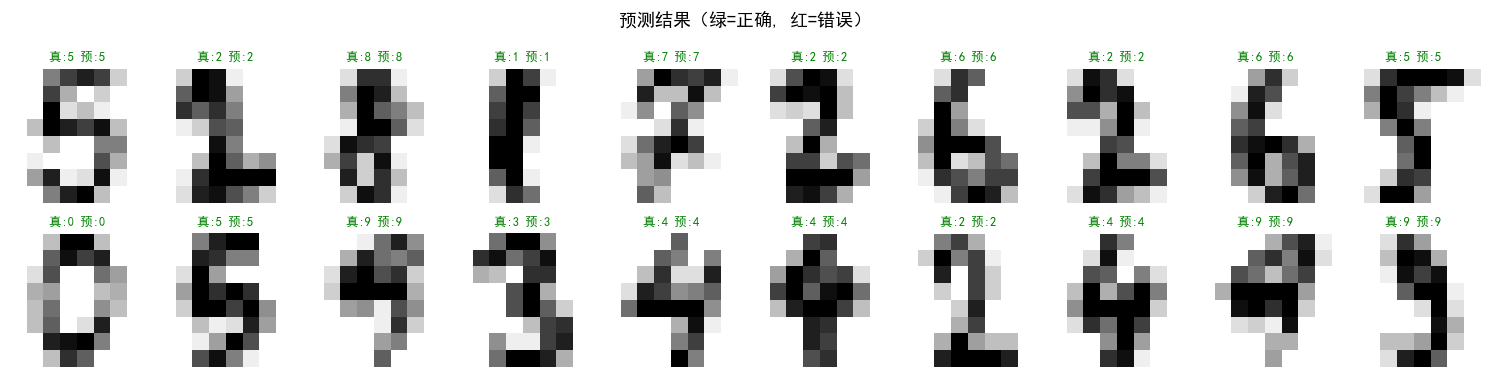

In [19]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    color = "green" if y_pred[i] == y_test[i] else "red"
    ax.set_title(f"真:{y_test[i]} 预:{y_pred[i]}", fontsize=9, color=color)
    ax.axis("off")

plt.suptitle("预测结果（绿=正确, 红=错误）", fontsize=13)
plt.tight_layout()
plt.show()

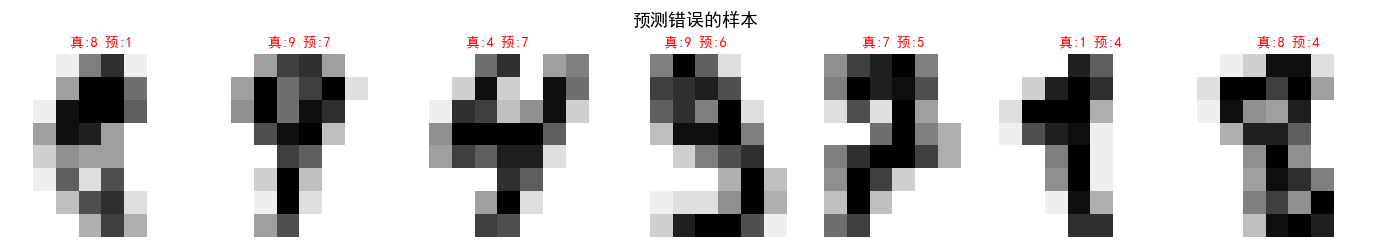

In [20]:
if len(errors) > 0:
    n_show = min(len(errors), 10)
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
    if n_show == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        idx = errors[i]
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
        ax.set_title(f"真:{y_test[idx]} 预:{y_pred[idx]}", fontsize=10, color="red")
        ax.axis("off")
    plt.suptitle("预测错误的样本", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("全部预测正确！")